In [37]:
import pandas as pd
import numpy as np
from utils import build_feature_matrix

### Feature Extraction & Outlier Analysis (1st Iteration) ### 

In [50]:
# Read metadata and preprocess the image paths
metadata = pd.read_json("metadata.jsonl", lines=True)
metadata = metadata.drop(["id"],axis=1)
metadata["image_path"] = metadata["image_path"].str.replace(
    "/content/drive/MyDrive/fruitveg_data/", "",
    regex=False
)

In [ ]:
# Build feature matrix
zip_path = "images.zip"
X, paths = build_feature_matrix(zip_path)

In [51]:
# Create DataFrame with features and paths
n_samples, n_features = X.shape
feature_cols = [f"f{i}" for i in range(n_features)]
df_feats = pd.DataFrame(X, columns=feature_cols)
df_feats["path"] = paths

In [54]:
# Merge features with metadata
df = df_feats.merge(metadata, left_on="path", right_on="image_path", how="inner")

In [56]:
feature_cols = [c for c in df.columns if c.startswith("f")]

# Group by class and z-score *within each class*
def zscore_group(g):
    return (g - g.mean()) / g.std()

df_z = df.groupby("class")[feature_cols].transform(zscore_group)


In [ ]:
df["outlier_score"] = df_z.abs().mean(axis=1)
threshold = 5.0
df["is_outlier"] = df["outlier_score"] > threshold

In [63]:
df.groupby("class")["is_outlier"].sum()

class
apple       91
banana      87
cucumber    49
orange      84
tomato      46
Name: is_outlier, dtype: int64

### Check if they're really extreme outliers

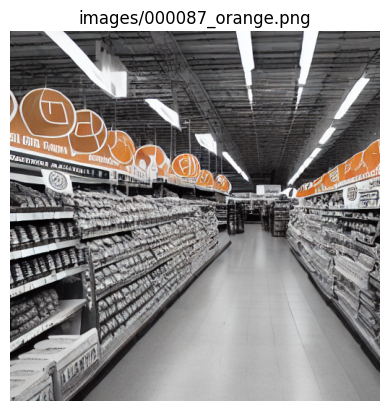

In [ ]:
import zipfile
from PIL import Image
import matplotlib.pyplot as plt

zip_path = "images.zip"
img_name = df[df["is_outlier"]==1].reset_index().loc[79,"image_path"]

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(img_name) as f:
        img = Image.open(f).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.title(img_name)
plt.show()


In [81]:
# Update the metadata with outlier information
metadata = metadata.merge(
    df[["path", "is_outlier"]],
    left_on="image_path",
    right_on="path",
    how="left"
)
metadata.to_json("metadata.jsonl", orient="records", lines=True)